# Customer Retention EDA — Credit Card Portfolio

Менеджер розничного кредитного портфеля видит рост оттока клиентов по кредитным картам и хочет понять его причины, чтобы проактивно работать с клиентами из группы риска, прежде чем они уйдут.

**Цель ноутбука:** очистить и обогатить данные, ответить на бизнес-вопросы заказчика, статистически проверить найденные закономерности и подготовить таблицу для визуализации в Tableau.

**Источник данных:** [Credit Card Customers (BankChurners)](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers), Kaggle, 10 127 клиентов, 21 признак после удаления служебных колонок.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 50)

## 1. Загрузка данных

In [ ]:
df = pd.read_csv("data/BankChurners.csv")
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 2. Удаление служебных колонок

In [ ]:
nb_cols = [c for c in df.columns if c.startswith("Naive_Bayes_Classifier")]

df = df.drop(columns=nb_cols)
print("Размер после удаления:", df.shape)


Размер после удаления: (10127, 21)


## 3. Переименование полей

In [ ]:
rename_map = {
    "Attrition_Flag": "Customer Status",
    "Customer_Age": "Age",
    "Dependent_count": "Dependents",
    "Education_Level": "Education",
    "Marital_Status": "Marital Status",
    "Income_Category": "Income",
    "Card_Category": "Card Type",
    "Months_on_book": "Tenure (months)",
    "Total_Relationship_Count": "Products Count",
    "Months_Inactive_12_mon": "Inactive Months",
    "Contacts_Count_12_mon": "Contacts",
    "Credit_Limit": "Credit Limit",
    "Total_Revolving_Bal": "Revolving Balance",
    "Avg_Open_To_Buy": "Open To Buy",
    "Total_Amt_Chng_Q4_Q1": "Amt Change Q4-Q1",
    "Total_Trans_Amt": "Trans Amount",
    "Total_Trans_Ct": "Trans Count",
    "Total_Ct_Chng_Q4_Q1": "Count Change Q4-Q1",
    "Avg_Utilization_Ratio": "Utilization Ratio",
}
df = df.rename(columns=rename_map)
df.columns.tolist()


['CLIENTNUM',
 'Customer Status',
 'Age',
 'Gender',
 'Dependents',
 'Education',
 'Marital Status',
 'Income',
 'Card Type',
 'Tenure (months)',
 'Products Count',
 'Inactive Months',
 'Contacts',
 'Credit Limit',
 'Revolving Balance',
 'Open To Buy',
 'Amt Change Q4-Q1',
 'Trans Amount',
 'Trans Count',
 'Count Change Q4-Q1',
 'Utilization Ratio']

## 4. Проверка пропусков и дублей клиентов

In [ ]:
print("Пропуски по колонкам:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "пропусков нет")

print("\nДубликаты CLIENTNUM:", df["CLIENTNUM"].duplicated().sum())
print("Уникальных клиентов:", df["CLIENTNUM"].nunique(), "из", len(df))


Пропуски по колонкам:
пропусков нет

Дубликаты CLIENTNUM: 0
Уникальных клиентов: 10127 из 10127


## 5. Целевая метрика: Is Churned / Churn Rate

In [ ]:
df["Is Churned"] = (df["Customer Status"] == "Attrited Customer").astype(int)

overall_churn = df["Is Churned"].mean()
print(f"Общий Churn Rate: {overall_churn:.2%}")
print(df["Customer Status"].value_counts(normalize=True).round(4) * 100)


Общий Churn Rate: 16.07%
Customer Status
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64


## 6. KPI Overview

In [ ]:
kpi = {
    "Total Customers": len(df),
    "Churn Rate": f"{df['Is Churned'].mean():.2%}",
    "Avg Products": round(df["Products Count"].mean(), 3),
    "Avg Utilization": f"{df['Utilization Ratio'].mean():.2%}",
}
for k, v in kpi.items():
    print(f"{k:16s}: {v}")


Total Customers : 10127
Churn Rate      : 16.07%
Avg Products    : 3.813
Avg Utilization : 27.49%


## 7. Вспомогательная функция: Churn Rate по сегменту

In [ ]:
def churn_by(data: pd.DataFrame, group_col: str) -> pd.Series:
    """Churn Rate по группам, отсортированный по убыванию."""
    return (
        data.groupby(group_col)["Is Churned"]
        .mean()
        .sort_values(ascending=False)
    )


def plot_churn_bar(series: pd.Series, title: str, xlabel: str):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(series.index.astype(str), series.values)
    ax.set_title(title, fontsize=12, loc="left")
    ax.set_ylabel("Churn Rate")
    ax.set_xlabel(xlabel)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for b, v in zip(bars, series.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.1%}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, series.max() * 1.25)
    plt.tight_layout()
    plt.show()


## 8. Отток по возрастным группам

Вопрос заказчика: *"есть ли возрастной сегмент, который уходит заметно чаще?"*

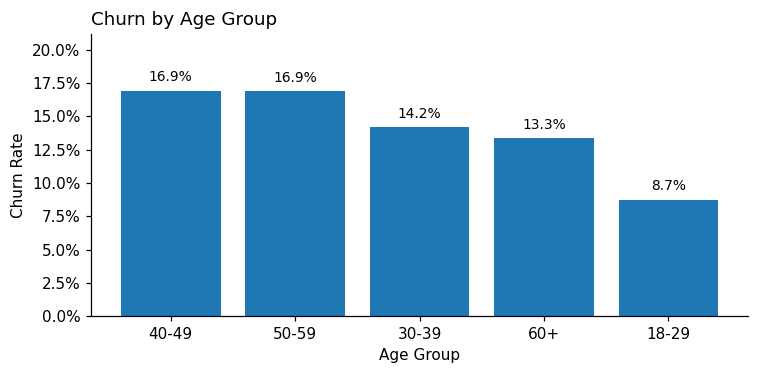

,Is Churned
Age Group,
40-49,16.9%
50-59,16.9%
30-39,14.2%
60+,13.3%
18-29,8.7%


In [ ]:
def age_group(age: int) -> str:
    if age < 30:
        return "18-29"
    elif age < 40:
        return "30-39"
    elif age < 50:
        return "40-49"
    elif age < 60:
        return "50-59"
    else:
        return "60+"


df["Age Group"] = df["Age"].apply(age_group)

age_churn = churn_by(df, "Age Group")
plot_churn_bar(age_churn, "Churn by Age Group", "Age Group")
age_churn.map(lambda x: f"{x:.1%}")


## 9. Отток по уровню дохода

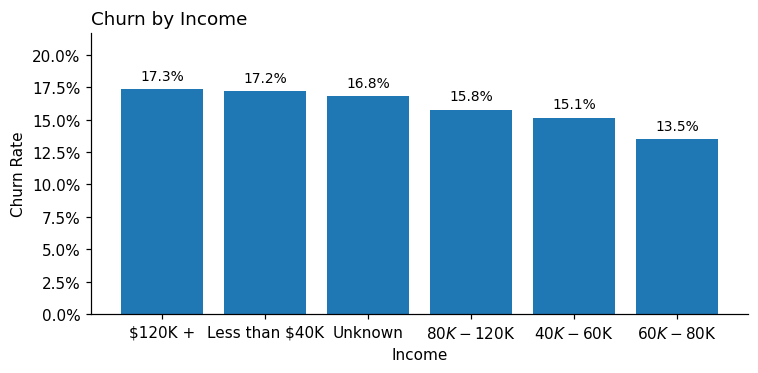

,Is Churned
Income,
$120K +,17.3%
Less than $40K,17.2%
Unknown,16.8%
$80K - $120K,15.8%
$40K - $60K,15.1%
$60K - $80K,13.5%


In [ ]:
income_churn = churn_by(df, "Income")
plot_churn_bar(income_churn, "Churn by Income", "Income")
income_churn.map(lambda x: f"{x:.1%}")


## 10. Отток по типу карты

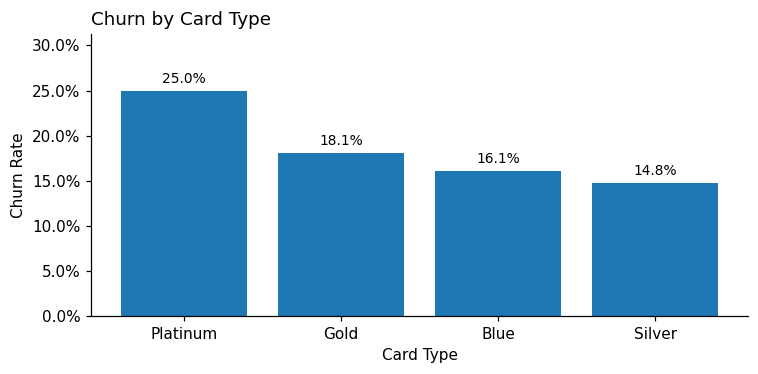

,Is Churned
Card Type,
Platinum,25.0%
Gold,18.1%
Blue,16.1%
Silver,14.8%


In [ ]:
card_churn = churn_by(df, "Card Type")
plot_churn_bar(card_churn, "Churn by Card Type", "Card Type")
card_churn.map(lambda x: f"{x:.1%}")


## 11. Отток по количеству продуктов

Проверяем гипотезу: клиенты с малым числом продуктов банка уходят чаще, чем клиенты с несколькими продуктами (кросс-продажи удерживают).

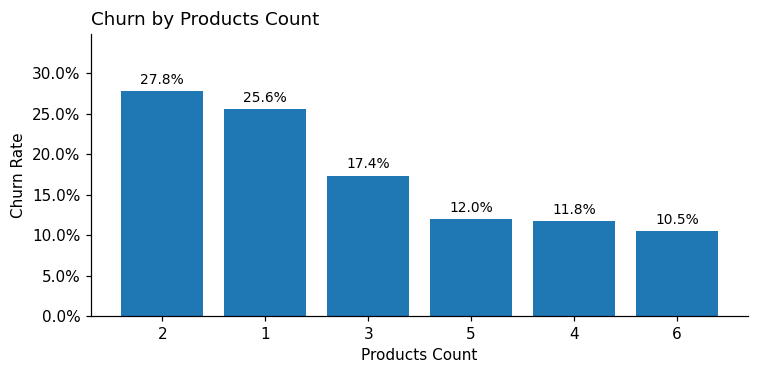

,Is Churned
Products Count,
2,27.8%
1,25.6%
3,17.4%
5,12.0%
4,11.8%
6,10.5%


In [ ]:
products_churn = churn_by(df, "Products Count")
plot_churn_bar(products_churn, "Churn by Products Count", "Products Count")
products_churn.map(lambda x: f"{x:.1%}")


## 12. Неактивность и отток

Вопрос заказчика: *"неактивность клиента — ранний сигнал ухода?"*

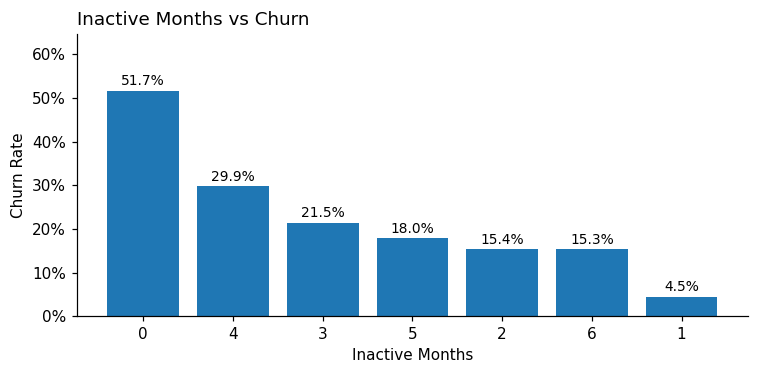

,Is Churned
Inactive Months,
0,51.7%
4,29.9%
3,21.5%
5,18.0%
2,15.4%
6,15.3%
1,4.5%


In [ ]:
inactive_churn = churn_by(df, "Inactive Months")
plot_churn_bar(inactive_churn, "Inactive Months vs Churn", "Inactive Months")
inactive_churn.map(lambda x: f"{x:.1%}")


## 13. Risk Segment — составное бизнес-правило

Комбинируем неактивность, число продуктов и утилизацию карты в одно правило

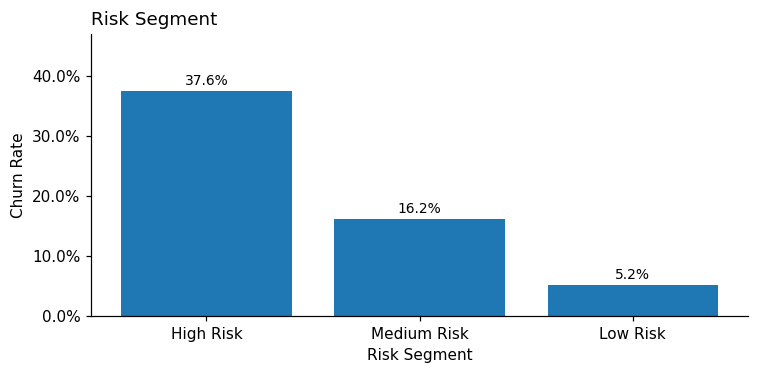

,Is Churned
Risk Segment,
High Risk,37.6%
Medium Risk,16.2%
Low Risk,5.2%


In [ ]:
def risk_segment(row) -> str:
    if row["Inactive Months"] >= 3 and row["Products Count"] <= 2:
        return "High Risk"
    elif row["Inactive Months"] >= 2 or row["Utilization Ratio"] > 0.7:
        return "Medium Risk"
    else:
        return "Low Risk"


df["Risk Segment"] = df.apply(risk_segment, axis=1)

risk_churn = churn_by(df, "Risk Segment")
plot_churn_bar(risk_churn, "Risk Segment", "Risk Segment")
risk_churn.map(lambda x: f"{x:.1%}")


## 14. Utilization Distribution

Смотрим, как распределены клиенты по уровню утилизации карты (0.0–1.0) и как в этом разрезе выглядит доля ушедших.

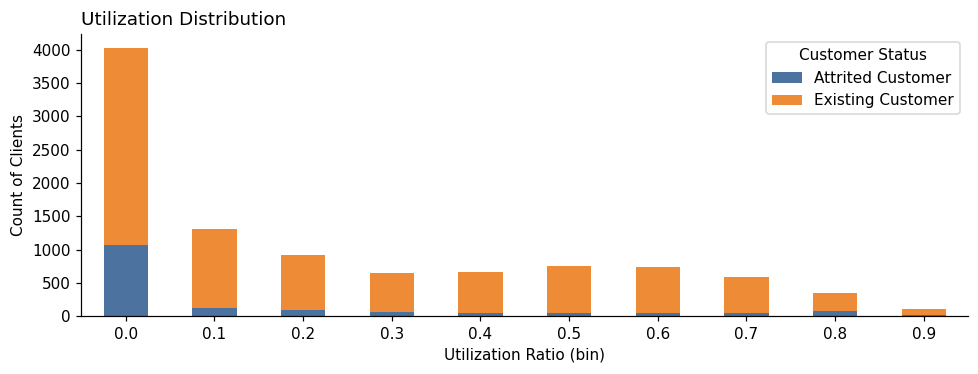

Доля клиентов с утилизацией близкой к 0: 29.6%
Из них доля ушедших: 32.7%


In [ ]:
bins = np.arange(0, 1.01, 0.1)
df["Utilization Bin"] = pd.cut(df["Utilization Ratio"], bins=bins, right=False, include_lowest=True)

util_pivot = (
    df.groupby(["Utilization Bin", "Customer Status"], observed=True)
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 3.5))
util_pivot.plot(kind="bar", stacked=True, ax=ax, color={"Existing Customer": "#ED8B37", "Attrited Customer": "#4C72A0"})
ax.set_title("Utilization Distribution", fontsize=12, loc="left")
ax.set_xlabel("Utilization Ratio (bin)")
ax.set_ylabel("Count of Clients")
ax.set_xticklabels([f"{i.left:.1f}" for i in util_pivot.index], rotation=0)
plt.tight_layout()
plt.show()

print("Доля клиентов с утилизацией близкой к 0:", f"{(df['Utilization Ratio'] < 0.05).mean():.1%}")
print("Из них доля ушедших:", f"{df.loc[df['Utilization Ratio'] < 0.05, 'Is Churned'].mean():.1%}")


## 15. Статистическая проверка значимости

Проверяем критерий хи-квадрат для независимости категориального признака и оттока (Is Churned).

In [ ]:
def chi2_test(data: pd.DataFrame, col: str) -> tuple[float, float]:
    table = pd.crosstab(data[col], data["Is Churned"])
    chi2, p, dof, _ = chi2_contingency(table)
    return chi2, p


for col in ["Age Group", "Income", "Card Type", "Products Count",
            "Inactive Months", "Risk Segment"]:
    chi2, p = chi2_test(df, col)
    signif = "значимо (p < 0.05)" if p < 0.05 else "НЕ значимо"
    print(f"{col:16s}: chi2 = {chi2:8.2f}, p-value = {p:.2e}  -> {signif}")


Age Group       : chi2 =    19.57, p-value = 6.08e-04  -> значимо (p < 0.05)
Income          : chi2 =    12.83, p-value = 2.50e-02  -> значимо (p < 0.05)
Card Type       : chi2 =     2.23, p-value = 5.25e-01  -> НЕ значимо
Products Count  : chi2 =   284.07, p-value = 2.66e-59  -> значимо (p < 0.05)
Inactive Months : chi2 =   396.46, p-value = 1.62e-82  -> значимо (p < 0.05)
Risk Segment    : chi2 =   520.57, p-value = 9.12e-114  -> значимо (p < 0.05)


Все проверенные срезы статистически значимо связаны с оттоком (p-value далеко ниже 0.05). Это значит, что сегменты на дашборде отражают реальные закономерности в данных, а не шум выборки.

## 16. Итоговые инсайты

In [ ]:
top_age = age_churn.index[0]
best_age = age_churn.index[-1]
low_prod_churn = products_churn.loc[products_churn.index.isin([1, 2])].mean()
high_prod_churn = products_churn.loc[products_churn.index.isin([4, 5, 6])].mean()
zero_inactive = inactive_churn.get(0, np.nan)
one_inactive = inactive_churn.get(1, np.nan)
high_risk = risk_churn.get("High Risk", np.nan)
low_risk = risk_churn.get("Low Risk", np.nan)

print("KEY INSIGHTS")
print("-" * 60)
print(f"- Возрастная группа {top_age} показывает самый высокий отток "
      f"(~{age_churn.iloc[0]:.1%}), а {best_age} самый низкий "
      f"(~{age_churn.iloc[-1]:.1%}).")
print(f"- Клиенты с 1-2 продуктами уходят чаще (~{low_prod_churn:.1%}), "
      f"чем клиенты с 4+ продуктами (~{high_prod_churn:.1%}).")
print(f"- Неактивность - сильный предиктор: 0 месяцев неактивности -> "
      f"{zero_inactive:.1%} оттока, 1 месяц -> {one_inactive:.1%}.")
print(f"- High Risk сегмент: {high_risk:.1%} оттока против {low_risk:.1%} "
      f"у Low Risk, разница в {high_risk/low_risk:.1f} раза.")
print(f"- Общий Churn Rate по базе: {overall_churn:.2%} "
      f"(10 127 клиентов, включая {int(df['Is Churned'].sum())} ушедших).")


KEY INSIGHTS
------------------------------------------------------------
- Возрастная группа 40-49 показывает самый высокий отток (~16.9%), а 18-29 самый низкий (~8.7%).
- Клиенты с 1-2 продуктами уходят чаще (~26.7%), чем клиенты с 4+ продуктами (~11.4%).
- Неактивность - сильный предиктор: 0 месяцев неактивности -> 51.7% оттока, 1 месяц -> 4.5%.
- High Risk сегмент: 37.6% оттока против 5.2% у Low Risk, разница в 7.2 раза.
- Общий Churn Rate по базе: 16.07% (10 127 клиентов, включая 1627 ушедших).
